In this notebook I'm going to obtain an overview, cleaning and formatting of the dataset before the EDA. 

In [1]:
import pandas as pd
import os
pd.set_option('display.max_columns', None)

In [2]:
# # change the format to reduce the size of the dataset

# df = pd.read_csv("../data/raw/ncr_ride_bookings.csv")
# df.to_parquet("../data/raw/rides.parquet", engine='fastparquet', index=False)

In [3]:
df_raw = pd.read_parquet("../data/raw/rides.parquet")

In [4]:
df_raw.head(15)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,None,NaN,None,NaN,None,NaN,NaN,NaN,NaN,None
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,None,NaN,None,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,None,NaN,None,NaN,None,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,None,NaN,None,NaN,None,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,None,NaN,None,NaN,None,737.0,48.21,4.1,4.3,UPI
5,2024-02-06,09:44:56,"""CNR4096693""",Completed,"""CID4670564""",Auto,AIIMS,Narsinghpur,5.1,18.1,NaN,None,NaN,None,NaN,None,316.0,4.85,4.1,4.6,UPI
6,2024-06-17,15:45:58,"""CNR2002539""",Completed,"""CID6800553""",Go Mini,Vaishali,Punjabi Bagh,7.1,20.4,NaN,None,NaN,None,NaN,None,640.0,41.24,4.0,4.1,UPI
7,2024-03-19,17:37:37,"""CNR6568000""",Completed,"""CID8610436""",Auto,Mayur Vihar,Cyber Hub,12.1,16.5,NaN,None,NaN,None,NaN,None,136.0,6.56,4.4,4.2,UPI
8,2024-09-14,12:49:09,"""CNR4510807""",No Driver Found,"""CID7873618""",Go Sedan,Noida Sector 62,Noida Sector 18,NaN,NaN,NaN,None,NaN,None,NaN,None,NaN,NaN,NaN,NaN,None
9,2024-12-16,19:06:48,"""CNR7721892""",Incomplete,"""CID5214275""",Auto,Rohini,Adarsh Nagar,6.1,26.0,NaN,None,NaN,None,1.0,Other Issue,135.0,10.36,NaN,NaN,Cash


In [5]:
df_raw.info(memory_usage = "deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

To do: 
1. Convert names into snake case
2. Map target variable with the right values
3. Remove quotes from string values in Booking ID and Customer ID
4. Downcast columns 
  - Data and time are object → convert into one datetime column
- Check the nulls?

## Convert names into snake case

In [6]:
import re 
df_columns_clean = df_raw.copy()
def to_snake_case(df):
    new_columns = []
    for col in df.columns:
        col = col.strip()
        col = re.sub(r'[\s\-]+', '_', col)
        col = re.sub(r'[^\w_]', '', col)
        col = col.lower()
        new_columns.append(col)
    
    df.columns = new_columns
    return df

df_columns_clean = to_snake_case(df_columns_clean)
print(df_columns_clean.columns.tolist())

['date', 'time', 'booking_id', 'booking_status', 'customer_id', 'vehicle_type', 'pickup_location', 'drop_location', 'avg_vtat', 'avg_ctat', 'cancelled_rides_by_customer', 'reason_for_cancelling_by_customer', 'cancelled_rides_by_driver', 'driver_cancellation_reason', 'incomplete_rides', 'incomplete_rides_reason', 'booking_value', 'ride_distance', 'driver_ratings', 'customer_rating', 'payment_method']


## Map target variable

In [7]:
df_target_mapped = df_columns_clean.copy()

booking_mapping = {
    "Completed": 0,
    "Cancelled by Driver": 1,
    "No Driver Found": 1,
    "Cancelled by Customer": 1,
    "Incomplete": 0
}

df_target_mapped['cancelled'] = df_target_mapped['booking_status'].map(booking_mapping)
del df_target_mapped["booking_status"]
df_target_mapped.head()

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,cancelled_rides_by_customer,reason_for_cancelling_by_customer,cancelled_rides_by_driver,driver_cancellation_reason,incomplete_rides,incomplete_rides_reason,booking_value,ride_distance,driver_ratings,customer_rating,payment_method,cancelled
0,2024-03-23,12:29:38,"""CNR5884300""","""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,None,NaN,None,NaN,None,NaN,NaN,NaN,NaN,None,1
1,2024-11-29,18:01:39,"""CNR1326809""","""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,None,NaN,None,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,0
2,2024-08-23,08:56:10,"""CNR8494506""","""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,None,NaN,None,NaN,None,627.0,13.58,4.9,4.9,Debit Card,0
3,2024-10-21,17:17:25,"""CNR8906825""","""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,None,NaN,None,NaN,None,416.0,34.02,4.6,5.0,UPI,0
4,2024-09-16,22:08:00,"""CNR1950162""","""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,None,NaN,None,NaN,None,737.0,48.21,4.1,4.3,UPI,0


## Remove quotes from string values in Booking ID and Customer ID

In [8]:
df_clean_quotes = df_target_mapped.copy()

cols_with_quotes = ["booking_id", 
                    "customer_id"]

for col in cols_with_quotes:
    df_clean_quotes[col] = df_clean_quotes[col].str.strip('"')

df_clean_quotes.head()

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,cancelled_rides_by_customer,reason_for_cancelling_by_customer,cancelled_rides_by_driver,driver_cancellation_reason,incomplete_rides,incomplete_rides_reason,booking_value,ride_distance,driver_ratings,customer_rating,payment_method,cancelled
0,2024-03-23,12:29:38,CNR5884300,CID1982111,eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,None,NaN,None,NaN,None,NaN,NaN,NaN,NaN,None,1
1,2024-11-29,18:01:39,CNR1326809,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,None,NaN,None,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,0
2,2024-08-23,08:56:10,CNR8494506,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,None,NaN,None,NaN,None,627.0,13.58,4.9,4.9,Debit Card,0
3,2024-10-21,17:17:25,CNR8906825,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,None,NaN,None,NaN,None,416.0,34.02,4.6,5.0,UPI,0
4,2024-09-16,22:08:00,CNR1950162,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,None,NaN,None,NaN,None,737.0,48.21,4.1,4.3,UPI,0


In [24]:
df_clean_quotes.head(20)

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,cancelled_rides_by_customer,reason_for_cancelling_by_customer,cancelled_rides_by_driver,driver_cancellation_reason,incomplete_rides,incomplete_rides_reason,booking_value,ride_distance,driver_ratings,customer_rating,payment_method,cancelled
0,2024-03-23,12:29:38,CNR5884300,CID1982111,eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,None,NaN,None,NaN,None,NaN,NaN,NaN,NaN,None,1
1,2024-11-29,18:01:39,CNR1326809,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,None,NaN,None,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,0
2,2024-08-23,08:56:10,CNR8494506,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,None,NaN,None,NaN,None,627.0,13.58,4.9,4.9,Debit Card,0
3,2024-10-21,17:17:25,CNR8906825,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,None,NaN,None,NaN,None,416.0,34.02,4.6,5.0,UPI,0
4,2024-09-16,22:08:00,CNR1950162,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,None,NaN,None,NaN,None,737.0,48.21,4.1,4.3,UPI,0
5,2024-02-06,09:44:56,CNR4096693,CID4670564,Auto,AIIMS,Narsinghpur,5.1,18.1,NaN,None,NaN,None,NaN,None,316.0,4.85,4.1,4.6,UPI,0
6,2024-06-17,15:45:58,CNR2002539,CID6800553,Go Mini,Vaishali,Punjabi Bagh,7.1,20.4,NaN,None,NaN,None,NaN,None,640.0,41.24,4.0,4.1,UPI,0
7,2024-03-19,17:37:37,CNR6568000,CID8610436,Auto,Mayur Vihar,Cyber Hub,12.1,16.5,NaN,None,NaN,None,NaN,None,136.0,6.56,4.4,4.2,UPI,0
8,2024-09-14,12:49:09,CNR4510807,CID7873618,Go Sedan,Noida Sector 62,Noida Sector 18,NaN,NaN,NaN,None,NaN,None,NaN,None,NaN,NaN,NaN,NaN,None,1
9,2024-12-16,19:06:48,CNR7721892,CID5214275,Auto,Rohini,Adarsh Nagar,6.1,26.0,NaN,None,NaN,None,1.0,Other Issue,135.0,10.36,NaN,NaN,Cash,0


## Recast columns

In [9]:
df_typed = df_clean_quotes.copy()

df_typed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   date                               150000 non-null  object 
 1   time                               150000 non-null  object 
 2   booking_id                         150000 non-null  object 
 3   customer_id                        150000 non-null  object 
 4   vehicle_type                       150000 non-null  object 
 5   pickup_location                    150000 non-null  object 
 6   drop_location                      150000 non-null  object 
 7   avg_vtat                           139500 non-null  float64
 8   avg_ctat                           102000 non-null  float64
 9   cancelled_rides_by_customer        10500 non-null   float64
 10  reason_for_cancelling_by_customer  10500 non-null   object 
 11  cancelled_rides_by_driver          2700

### Temporal features

Create column `datetime` and convert it along`date` to datetime. Keep `time` as object because datetime needs a date (or a dummy date) to be converted

In [10]:
df_typed["datetime"] = pd.to_datetime(df_typed["date"].astype(str) + " " + df_typed["time"].astype(str))
df_typed["date"] = pd.to_datetime(df_typed["date"])

df_typed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   date                               150000 non-null  datetime64[ns]
 1   time                               150000 non-null  object        
 2   booking_id                         150000 non-null  object        
 3   customer_id                        150000 non-null  object        
 4   vehicle_type                       150000 non-null  object        
 5   pickup_location                    150000 non-null  object        
 6   drop_location                      150000 non-null  object        
 7   avg_vtat                           139500 non-null  float64       
 8   avg_ctat                           102000 non-null  float64       
 9   cancelled_rides_by_customer        10500 non-null   float64       
 10  reason_for_cancellin

### Categorical
1. Columns with "object" data type and no nulls are directly turned into Category
   
2. Columns with "object" data type and nulls are turned into Category based on threshold. Threshold is set to 0.5, that means less than 50% of values are unique. If threshold is less that this value, the column will be turned into string[pyarrow] type. 

In [11]:
cat_ambiguous = ["reason_for_cancelling_by_customer",
                 "driver_cancellation_reason",
                 "incomplete_rides_reason",
                 "booking_id", 
               "customer_id" ]
cat_threshold = 0.5

for col in cat_ambiguous:
    if col in df_typed.columns:
        num_unique = df_typed[col].nunique(dropna = False)
        ratio_unique = num_unique/len(df_typed)

        if ratio_unique <= cat_threshold:
            df_typed[col] = df_typed[col].astype("category")
            print(f"- Column {col} has been transformed into Category")
            print(f"Ratio of the column: {ratio_unique:.4%}")
        else:
            df_typed[col] = df_typed[col].astype("string[pyarrow]")
            print(f"- Column {col} has been transformed into string[pyarrow]")
            print(f"Ratio of the column: {ratio_unique:.4%}")


- Column reason_for_cancelling_by_customer has been transformed into Category
Ratio of the column: 0.0040%
- Column driver_cancellation_reason has been transformed into Category
Ratio of the column: 0.0033%
- Column incomplete_rides_reason has been transformed into Category
Ratio of the column: 0.0027%
- Column booking_id has been transformed into string[pyarrow]
Ratio of the column: 99.1780%
- Column customer_id has been transformed into string[pyarrow]
Ratio of the column: 99.1920%


In [12]:
cat_columns = ["vehicle_type", 
               "pickup_location", 
               "drop_location",
               "payment_method"]

for col in cat_columns:
    if col in df_typed.columns:
        df_typed[col] = df_typed[col].astype("category")
        print(f"- Column {col} has been transformed into Category")

- Column vehicle_type has been transformed into Category
- Column pickup_location has been transformed into Category
- Column drop_location has been transformed into Category
- Column payment_method has been transformed into Category


### Numerical

i usually perform type optimization since I'm working on my personal computer. In this case, since the dataset is not very big, I will only transform the numerical data into float32

In [13]:
numerical_columns = ["avg_vtat", 
                 "avg_ctat", 
                 "cancelled_rides_by_customer",
                 "cancelled_rides_by_driver",
                 "incomplete_rides",
                 "booking_value",
                 "ride_distance",
                 "driver_ratings",
                 "customer_rating",
                 "cancelled"]

for col in numerical_columns:
    if col in df_typed.columns:
        df_typed[col] = df_typed[col].astype("float32")
        print(f"- Column {col} has been transformed into float32")


- Column avg_vtat has been transformed into float32
- Column avg_ctat has been transformed into float32
- Column cancelled_rides_by_customer has been transformed into float32
- Column cancelled_rides_by_driver has been transformed into float32
- Column incomplete_rides has been transformed into float32
- Column booking_value has been transformed into float32
- Column ride_distance has been transformed into float32
- Column driver_ratings has been transformed into float32
- Column customer_rating has been transformed into float32
- Column cancelled has been transformed into float32


In [14]:
df_typed.head()

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,cancelled_rides_by_customer,reason_for_cancelling_by_customer,cancelled_rides_by_driver,driver_cancellation_reason,incomplete_rides,incomplete_rides_reason,booking_value,ride_distance,driver_ratings,customer_rating,payment_method,cancelled,datetime
0,2024-03-23,12:29:38,CNR5884300,CID1982111,eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2024-03-23 12:29:38
1,2024-11-29,18:01:39,CNR1326809,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.000000,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.730000,NaN,NaN,UPI,0.0,2024-11-29 18:01:39
2,2024-08-23,08:56:10,CNR8494506,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.799999,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.580000,4.9,4.9,Debit Card,0.0,2024-08-23 08:56:10
3,2024-10-21,17:17:25,CNR8906825,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,28.500000,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.020000,4.6,5.0,UPI,0.0,2024-10-21 17:17:25
4,2024-09-16,22:08:00,CNR1950162,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.600000,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.209999,4.1,4.3,UPI,0.0,2024-09-16 22:08:00


In [23]:
df_typed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 14378 to 55202
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   date                               150000 non-null  datetime64[ns]
 1   time                               150000 non-null  object        
 2   booking_id                         150000 non-null  string        
 3   customer_id                        150000 non-null  string        
 4   vehicle_type                       150000 non-null  category      
 5   pickup_location                    150000 non-null  category      
 6   drop_location                      150000 non-null  category      
 7   avg_vtat                           139500 non-null  float32       
 8   avg_ctat                           102000 non-null  float32       
 9   cancelled_rides_by_customer        10500 non-null   float32       
 10  reason_for_cancelling_

## Overview

### Categorical

In [15]:
cat_cols = df_typed.select_dtypes(include="category").columns


In [16]:
for col in cat_cols:
    print(f"\n=== {col} ===")
    print(df_typed[col].value_counts(dropna=False))



=== vehicle_type ===
vehicle_type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64

=== pickup_location ===
pickup_location
Khandsa             949
Barakhamba Road     946
Saket               931
Badarpur            921
Pragati Maidan      920
                   ... 
Mandi House         800
Noida Sector 18     799
Laxmi Nagar         797
Ashok Vihar         796
Ghitorni Village    790
Name: count, Length: 176, dtype: int64

=== drop_location ===
drop_location
Ashram              936
Basai Dhankot       917
Lok Kalyan Marg     916
Narsinghpur         913
Cyber Hub           912
                   ... 
MG Road             799
Bhiwadi             792
Shivaji Park        786
Anand Vihar ISBT    784
Huda City Centre    774
Name: count, Length: 176, dtype: int64

=== reason_for_cancelling_by_customer ===
reason_for_cancelling_by_customer
NaN              

### String

In [17]:
string_cols = df_typed.select_dtypes(include="string[pyarrow]").columns


In [18]:
for col in string_cols:
    print(f"\n=== {col} ===")
    print(df_typed[col].value_counts(dropna=False))


=== booking_id ===
booking_id
CNR7908610    3
CNR9603232    3
CNR3648267    3
CNR2726142    3
CNR7199036    3
             ..
CNR6500631    1
CNR2468611    1
CNR6358306    1
CNR3030099    1
CNR3447390    1
Name: count, Length: 148767, dtype: int64[pyarrow]

=== customer_id ===
customer_id
CID6468528    3
CID6715450    3
CID7828101    3
CID4523979    3
CID8727691    3
             ..
CID4337371    1
CID2325623    1
CID9925486    1
CID9415487    1
CID4108667    1
Name: count, Length: 148788, dtype: int64[pyarrow]


### Numerical

In [19]:
df_typed.describe()

,date,avg_vtat,avg_ctat,cancelled_rides_by_customer,cancelled_rides_by_driver,incomplete_rides,booking_value,ride_distance,driver_ratings,customer_rating,cancelled,datetime
count,150000,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000,150000.000000,150000
mean,2024-06-30 16:42:40.320000,8.456351,29.149635,1.0,1.0,1.0,508.295929,24.637012,4.230993,4.404584,0.320000,2024-07-01 07:14:41.251033344
min,2024-01-01 00:00:00,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000,0.000000,2024-01-01 00:19:34
25%,2024-03-31 00:00:00,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000,0.000000,2024-03-31 22:55:36.249999872
50%,2024-07-01 00:00:00,8.300000,28.799999,1.0,1.0,1.0,414.000000,23.719999,4.300000,4.500000,0.000000,2024-07-01 09:24:52.500000
75%,2024-09-30 00:00:00,11.300000,36.799999,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000,1.000000,2024-09-30 13:46:07.249999872
max,2024-12-30 00:00:00,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000,1.000000,2024-12-30 23:36:11
std,NaN,3.773564,8.902577,0.0,0.0,0.0,395.805756,14.002138,0.436871,0.437819,0.466478,NaN


array([[<Axes: title={'center': 'date'}>,
        <Axes: title={'center': 'avg_vtat'}>,
        <Axes: title={'center': 'avg_ctat'}>],
       [<Axes: title={'center': 'cancelled_rides_by_customer'}>,
        <Axes: title={'center': 'cancelled_rides_by_driver'}>,
        <Axes: title={'center': 'incomplete_rides'}>],
       [<Axes: title={'center': 'booking_value'}>,
        <Axes: title={'center': 'ride_distance'}>,
        <Axes: title={'center': 'driver_ratings'}>],
       [<Axes: title={'center': 'customer_rating'}>,
        <Axes: title={'center': 'cancelled'}>,
        <Axes: title={'center': 'datetime'}>]], dtype=object)

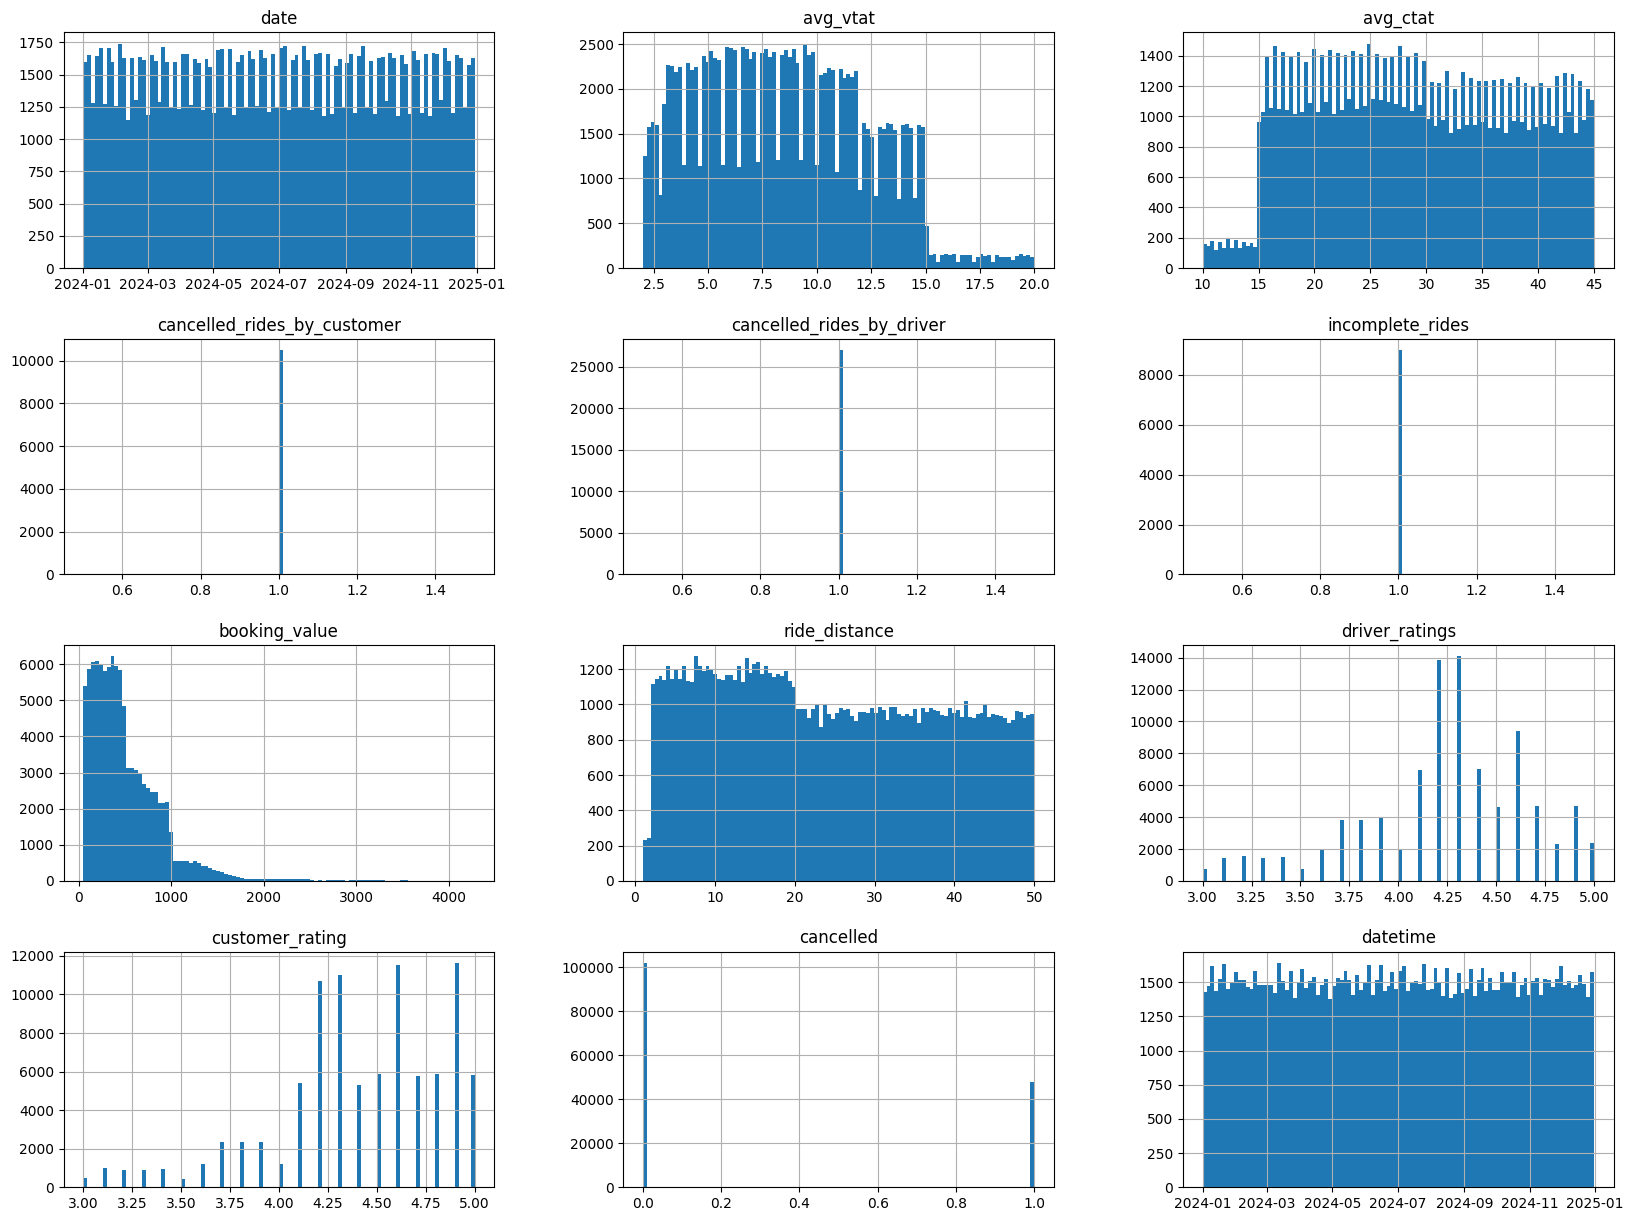

In [20]:
df_typed.hist(figsize=(20, 15), bins = 100)

## Train/test split

The dataset goes from the 1st of January 2024 to the 30th December 2024, I will split it following 70% train, 15% val, 15% test.

In [ ]:
df_typed = df_typed.sort_values("date")

train_end = "2024-09-30"  
val_end = "2024-11-30"

train_df = df_typed[df_typed["date"] <= train_end]
val_df   = df_typed[(df_typed["date"] > train_end) & (df_typed["date"] <= val_end)]
test_df  = df_typed[df_typed["date"] > val_end]

## Save dataset

In [22]:
output_dir = "../data/bronze"
os.makedirs(output_dir, exist_ok=True)  

train_df.to_parquet(os.path.join(output_dir, "train.parquet"), index=False)
val_df.to_parquet(os.path.join(output_dir, "val.parquet"), index=False)
test_df.to_parquet(os.path.join(output_dir, "test.parquet"), index=False)